In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
## Step 1: Load and Preprocess Data
# Load training and test datasets
df_train = pd.read_csv('/content/drive/MyDrive/trainset.csv')
df_test = pd.read_csv('/content/drive/MyDrive/testset.csv')

In [39]:

df_train.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,357.385559,361.151062,355.959839,359.288177,359.288177,5115500
1,2013-01-03,360.122742,363.600128,358.031342,359.496826,359.496826,4666500
2,2013-01-04,362.313507,368.339294,361.488861,366.600616,366.600616,5562800
3,2013-01-07,365.348755,367.301056,362.929504,365.001007,365.001007,3332900
4,2013-01-08,365.393463,365.771027,359.874359,364.280701,364.280701,3373900


In [40]:
df_test.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,1048.339966,1066.939941,1045.229980,1065.000000,1065.000000,1237600
1,2018-01-03,1064.310059,1086.290039,1063.209961,1082.479980,1082.479980,1430200
2,2018-01-04,1088.000000,1093.569946,1084.001953,1086.400024,1086.400024,1004600
3,2018-01-05,1094.000000,1104.250000,1092.000000,1102.229980,1102.229980,1279100
4,2018-01-08,1102.229980,1111.270020,1101.619995,1106.939941,1106.939941,1047600


In [4]:
# Use closing prices
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [5]:
# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [6]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [7]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [8]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [9]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [26]:
## Step 2: Define RNN Model
class RNNModel(nn.Module):
    def __init__(self,input_size=1,hidden_size=64,num_layers=2,output_size=1):
      super(RNNModel,self).__init__()
      self.rnn = nn.RNN(input_size,hidden_size,num_layers,batch_first=True)
      self.fc = nn.Linear(hidden_size,output_size)

    def forward(self,x):
      out, _ = self.rnn(x)
      out = self.fc(out[:,-1,:])
      return out

In [27]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [28]:
!pip install torchinfo

In [29]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model)

Layer (type:depth-idx)                   Param #
RNNModel                                 --
├─RNN: 1-1                               12,608
├─Linear: 1-2                            65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0

In [30]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)

In [33]:
## Step 3: Train the Model

# Write your code here
def train_model(model,train_loader,criterion,optimizer,epochs=30):
  train_losses  = []
  model.train()

  for epoch in range(epochs):
    total_loss = 0
    for x_batch,y_batch in train_loader:
      x_batch,y_batch = x_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()
      outputs = model(x_batch)
      loss = criterion(outputs,y_batch)
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))
    print(f'Epoch [{epoch+1}/{epochs}], Loss:{total_loss/len(train_loader):.4f}')

    # Plot training loss
  print('Name: Vikamuhan reddy')
  print('Register Number: 212223240181')
  plt.plot(train_losses, label='Training Loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE Loss')
  plt.title('Training Loss Over Epochs')
  plt.legend()
  plt.show()



Epoch [1/30], Loss:0.0425
Epoch [2/30], Loss:0.0364
Epoch [3/30], Loss:0.0277
Epoch [4/30], Loss:0.0158
Epoch [5/30], Loss:0.0031
Epoch [6/30], Loss:0.0009
Epoch [7/30], Loss:0.0006
Epoch [8/30], Loss:0.0006
Epoch [9/30], Loss:0.0006
Epoch [10/30], Loss:0.0006
Epoch [11/30], Loss:0.0006
Epoch [12/30], Loss:0.0006
Epoch [13/30], Loss:0.0006
Epoch [14/30], Loss:0.0006
Epoch [15/30], Loss:0.0006
Epoch [16/30], Loss:0.0005
Epoch [17/30], Loss:0.0005
Epoch [18/30], Loss:0.0005
Epoch [19/30], Loss:0.0005
Epoch [20/30], Loss:0.0005
Epoch [21/30], Loss:0.0005
Epoch [22/30], Loss:0.0005
Epoch [23/30], Loss:0.0005
Epoch [24/30], Loss:0.0005
Epoch [25/30], Loss:0.0005
Epoch [26/30], Loss:0.0005
Epoch [27/30], Loss:0.0005
Epoch [28/30], Loss:0.0005
Epoch [29/30], Loss:0.0005
Epoch [30/30], Loss:0.0005
Name: Vikamuhan reddy
Register Number: 212223240181


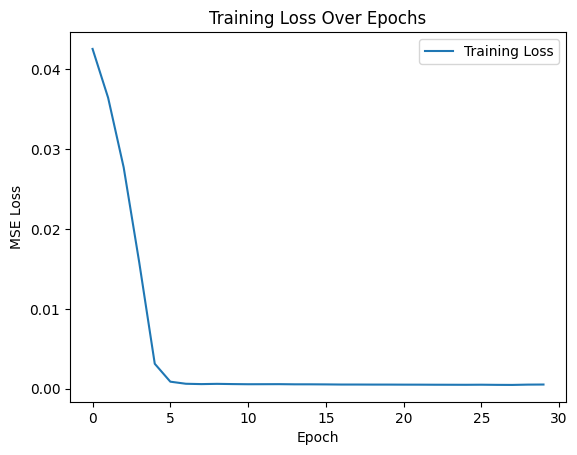

In [34]:
train_model(model,train_loader,criterion,optimizer)

Name:                 
Register Number:     


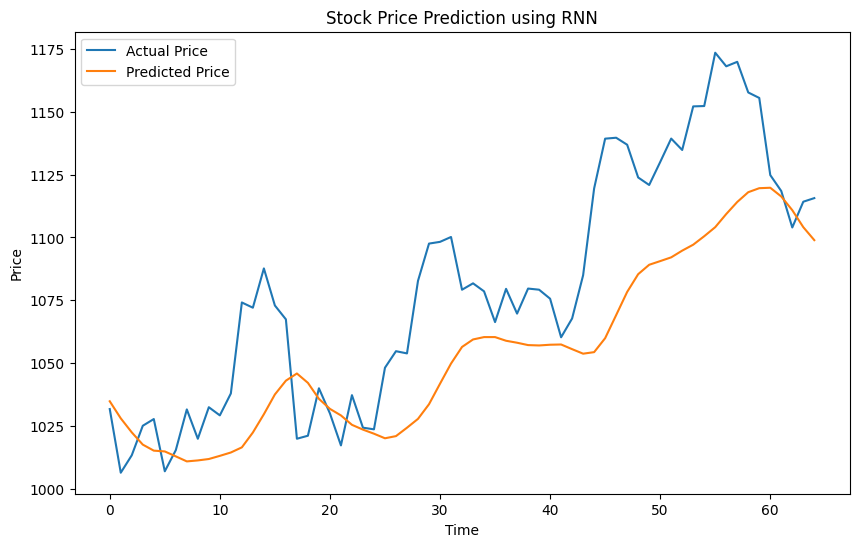

Predicted Price: [1098.9412]
Actual Price: [1115.65]


In [35]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

# Plot the predictions vs actual prices
print('Name:                 ')
print('Register Number:     ')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')